Strategy # 1A: Simple Moving Average (Long only - Using 5-minute data)

We determine the 12-period simple moving average (referred to as 'SMA12') and compare it with the price at that time. We (subjectively) select 12 since SMA12 would be the average price over one hour.

There are two conditions which we check.

If the price is greater than the SMA12, we go long. We continue to stay invested until the square-off condition is satisfied.

When the price becomes less than the SMA12, we square off our long position.

Our trading rules can be stated as

Buy when price > SMA12
Square off when price <= SMA12

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')

# For high level interative plots
import plotly.express as px

# To show graphs in same notebook window
%matplotlib inline

In [2]:
end1 = datetime.date(2026, 5, 29)
start1 = end1 - pd.Timedelta(days=30)

In [3]:
df = yf.download("NVDA", start=start1, end=end1, interval="5m", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [4]:
df

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
Datetime,,,,,,
2026-04-29 13:30:00+00:00,211.029999,211.029999,212.714996,210.399994,212.714996,8197139
2026-04-29 13:35:00+00:00,211.705002,211.705002,211.809998,210.440094,211.014999,2664037
2026-04-29 13:40:00+00:00,211.001007,211.001007,212.000000,210.764999,211.700806,2248339
2026-04-29 13:45:00+00:00,210.514999,210.514999,211.000107,210.300003,211.000000,2261793
2026-04-29 13:50:00+00:00,211.380005,211.380005,211.459702,210.429993,210.514999,1900128
...,...,...,...,...,...,...
2026-05-28 19:35:00+00:00,214.384995,214.384995,214.389999,214.024994,214.089996,924500
2026-05-28 19:40:00+00:00,214.229996,214.229996,214.434998,214.070007,214.384995,990467


In [5]:
df.shape

(1638, 6)

In [6]:
df.columns

MultiIndex([('Adj Close', 'NVDA'),
            (    'Close', 'NVDA'),
            (     'High', 'NVDA'),
            (      'Low', 'NVDA'),
            (     'Open', 'NVDA'),
            (   'Volume', 'NVDA')],
           names=['Price', 'Ticker'])

In [7]:
df.columns = df.columns.droplevel(1)
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [8]:
df1 = df.copy()
df1

Price,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-04-29 13:30:00+00:00,211.029999,211.029999,212.714996,210.399994,212.714996,8197139
2026-04-29 13:35:00+00:00,211.705002,211.705002,211.809998,210.440094,211.014999,2664037
2026-04-29 13:40:00+00:00,211.001007,211.001007,212.000000,210.764999,211.700806,2248339
2026-04-29 13:45:00+00:00,210.514999,210.514999,211.000107,210.300003,211.000000,2261793
2026-04-29 13:50:00+00:00,211.380005,211.380005,211.459702,210.429993,210.514999,1900128
...,...,...,...,...,...,...
2026-05-28 19:35:00+00:00,214.384995,214.384995,214.389999,214.024994,214.089996,924500
2026-05-28 19:40:00+00:00,214.229996,214.229996,214.434998,214.070007,214.384995,990467
2026-05-28 19:45:00+00:00,214.160095,214.160095,214.490005,214.160004,214.210007,923049


In [9]:
df1['cc_returns'] = df1['Close'].pct_change()
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns
Datetime,,,,,,,
2026-04-29 13:30:00+00:00,211.029999,211.029999,212.714996,210.399994,212.714996,8197139,NaN
2026-04-29 13:35:00+00:00,211.705002,211.705002,211.809998,210.440094,211.014999,2664037,0.003199
2026-04-29 13:40:00+00:00,211.001007,211.001007,212.000000,210.764999,211.700806,2248339,-0.003325
2026-04-29 13:45:00+00:00,210.514999,210.514999,211.000107,210.300003,211.000000,2261793,-0.002303
2026-04-29 13:50:00+00:00,211.380005,211.380005,211.459702,210.429993,210.514999,1900128,0.004109
...,...,...,...,...,...,...,...
2026-05-28 19:35:00+00:00,214.384995,214.384995,214.389999,214.024994,214.089996,924500,0.001331
2026-05-28 19:40:00+00:00,214.229996,214.229996,214.434998,214.070007,214.384995,990467,-0.000723
2026-05-28 19:45:00+00:00,214.160095,214.160095,214.490005,214.160004,214.210007,923049,-0.000326


In [11]:
sma = 12
df1['sma'] = df1['Close'].rolling(window=sma).mean()
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns,sma
Datetime,,,,,,,,
2026-04-29 13:30:00+00:00,211.029999,211.029999,212.714996,210.399994,212.714996,8197139,NaN,NaN
2026-04-29 13:35:00+00:00,211.705002,211.705002,211.809998,210.440094,211.014999,2664037,0.003199,NaN
2026-04-29 13:40:00+00:00,211.001007,211.001007,212.000000,210.764999,211.700806,2248339,-0.003325,NaN
2026-04-29 13:45:00+00:00,210.514999,210.514999,211.000107,210.300003,211.000000,2261793,-0.002303,NaN
2026-04-29 13:50:00+00:00,211.380005,211.380005,211.459702,210.429993,210.514999,1900128,0.004109,NaN
...,...,...,...,...,...,...,...,...
2026-05-28 19:35:00+00:00,214.384995,214.384995,214.389999,214.024994,214.089996,924500,0.001331,214.313750
2026-05-28 19:40:00+00:00,214.229996,214.229996,214.434998,214.070007,214.384995,990467,-0.000723,214.271249
2026-05-28 19:45:00+00:00,214.160095,214.160095,214.490005,214.160004,214.210007,923049,-0.000326,214.235432


In [13]:
df1['position'] = np.where((df1['Close'] > df1['sma']),1,0)
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns,sma,position
Datetime,,,,,,,,,
2026-04-29 13:30:00+00:00,211.029999,211.029999,212.714996,210.399994,212.714996,8197139,NaN,NaN,0
2026-04-29 13:35:00+00:00,211.705002,211.705002,211.809998,210.440094,211.014999,2664037,0.003199,NaN,0
2026-04-29 13:40:00+00:00,211.001007,211.001007,212.000000,210.764999,211.700806,2248339,-0.003325,NaN,0
2026-04-29 13:45:00+00:00,210.514999,210.514999,211.000107,210.300003,211.000000,2261793,-0.002303,NaN,0
2026-04-29 13:50:00+00:00,211.380005,211.380005,211.459702,210.429993,210.514999,1900128,0.004109,NaN,0
...,...,...,...,...,...,...,...,...,...
2026-05-28 19:35:00+00:00,214.384995,214.384995,214.389999,214.024994,214.089996,924500,0.001331,214.313750,1
2026-05-28 19:40:00+00:00,214.229996,214.229996,214.434998,214.070007,214.384995,990467,-0.000723,214.271249,0
2026-05-28 19:45:00+00:00,214.160095,214.160095,214.490005,214.160004,214.210007,923049,-0.000326,214.235432,0


In [14]:
df1['position'] = df1['position'].shift(1)

In [18]:
df1['strategy_returns'] = df1['cc_returns'] * df1['position']
df1['strategy_returns'] = 1 + df1['strategy_returns']
df1['cc_returns'] = 1 + df1['cc_returns']

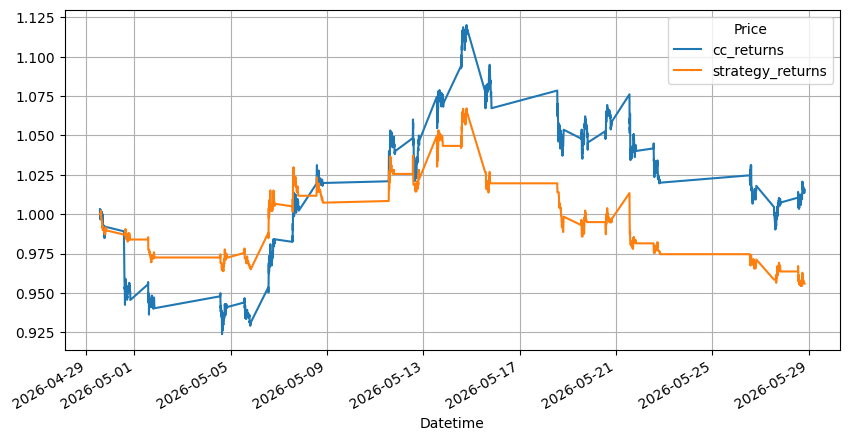

In [23]:
df1[['cc_returns', 'strategy_returns']].cumprod().plot(grid=True, figsize=(10, 5));
plt.show()

In [24]:
print('Buy and hold returns : ', np.round(df1['cc_returns'].cumprod()[-1]-1, 2))
print('Strategy returns : ', np.round(df1['strategy_returns'].cumprod()[-1]-1, 2))

Buy and hold returns :  0.02
Strategy returns :  -0.04
